# 6) K-nearest neighbors

- Type of model: SUPERVISED
- Model type of approach: distance-based / instance-based learning

In [5]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold

PROC_DIR = Path("./artifacts")
FIG_DIR = Path("./figures")
RESULTS_DIR = PROC_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(PROC_DIR / "features.csv")
sel = json.loads((PROC_DIR / "feature_selection.json").read_text())

y = (df["label"] == "bumpy").to_numpy().astype(int)

N_FOLDS = sel["n_folds"]
ALL = sel["all"]

print(f"{len(df)} windows, "
    f"{df['recording_id'].nunique()} recordings, "
    f"{df['participant'].nunique()} participants")

print(f"{len(sel['kept'])} features kept by the filters, "
    f"{len(sel['all'])} candidates")

768 windows, 26 recordings, 3 participants
52 features kept by the filters, 66 candidates


## 6.1 Cross-validation setup

In [6]:
# Split iterators: lists of (train_mask, test_mask) over windows

SPLITS = {
    "grouped folds": [((df["fold"] != k).to_numpy(),(df["fold"] == k).to_numpy())
        for k in range(N_FOLDS)],
    
    "leave-one-participant-out": [(
            (df["participant"] != p).to_numpy(),
            (df["participant"] == p).to_numpy())
        for p in sorted(df["participant"].unique())],}

In [7]:
for name, splits in SPLITS.items():
    print(name, len(splits))

    for i, (tr, te) in enumerate(splits):
        print(
            f"  split {i}: "
            f"train={tr.sum()}, test={te.sum()}"
        )

grouped folds 4
  split 0: train=578, test=190
  split 1: train=580, test=188
  split 2: train=569, test=199
  split 3: train=577, test=191
leave-one-participant-out 3
  split 0: train=570, test=198
  split 1: train=476, test=292
  split 2: train=490, test=278


## 6.2 KNN model

In [9]:
def knn(k=5, weights="uniform", metric="euclidean"):
    return Pipeline([("scaler", StandardScaler()),("knn", KNeighborsClassifier(
            n_neighbors=k,
            weights=weights,
            metric=metric))])

## 6.3 Number of neighbors

In [10]:
K_VALUES = [1, 3, 5, 7, 9, 11, 15, 21]

In [11]:
model = knn(k=5)
print(model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(metric='euclidean'))])


In [12]:
def cv_accuracy(splits, feats, **params):
    tr_acc, te_acc = [], []

    for tr, te in splits:
        clf = knn(**params).fit(
            df.loc[tr, feats],
            y[tr])

        tr_acc.append(clf.score(df.loc[tr, feats], y[tr]))

        te_acc.append(clf.score(df.loc[te, feats], y[te]))

    return (
        np.mean(tr_acc),
        np.mean(te_acc),
        np.min(te_acc))

In [13]:
rows = []

for s in SPLITS:
    for k in K_VALUES:
        train, test, worst = cv_accuracy(SPLITS[s],ALL,k=k)

        rows.append({
            "split": s,
            "k": k,
            "train": train,
            "test": test,
            "worst test": worst})

k_curve = pd.DataFrame(rows)

k_curve

,split,k,train,test,worst test
0,grouped folds,1,1.000000,0.909999,0.868421
1,grouped folds,3,0.983493,0.916350,0.848168
2,grouped folds,5,0.973068,0.921606,0.853403
3,grouped folds,7,0.967444,0.915135,0.827225
4,grouped folds,9,0.966123,0.921627,0.848168
5,grouped folds,11,0.964809,0.920371,0.848168
6,grouped folds,15,0.963093,0.925634,0.858639
7,grouped folds,21,0.958314,0.928206,0.858639
8,leave-one-participant-out,1,1.000000,0.827900,0.777778
9,leave-one-participant-out,3,0.983510,0.816855,0.752525


In [15]:
INNER_K_VALUES = [1, 3, 5, 7, 9, 11, 15, 21]


def nested_knn(tr, te, feats):
    inner = GroupKFold(n_splits=4).split(
        df.loc[tr, feats],
        y[tr],
        groups=df.loc[tr, "recording_id"])

    inner = [(
            np.isin(np.arange(len(df)), np.flatnonzero(tr)[a]),
            np.isin(np.arange(len(df)), np.flatnonzero(tr)[b]))
        for a, b in inner]

    best_k = max(
        INNER_K_VALUES,
        key=lambda k: cv_accuracy(inner,feats,k=k)[1])

    clf = knn(k=best_k).fit(df.loc[tr, feats],y[tr])

    return clf.predict(df.loc[te, feats]), best_k

In [17]:
nested_results = {}

for split_name, splits in SPLITS.items():
    print(f"\n{split_name}")

    split_results = []

    for i, (tr, te) in enumerate(splits):
        pred, best_k = nested_knn(tr, te, ALL)

        split_results.append({
            "split": i,
            "test_idx": np.flatnonzero(te),
            "y_true": y[te],
            "y_pred": pred,
            "best_k": best_k
        })

        print(
            f"  split {i}: "
            f"k={best_k}, "
            f"test samples={te.sum()}"
        )

    nested_results[split_name] = split_results


grouped folds
  split 0: k=9, test samples=190
  split 1: k=21, test samples=188
  split 2: k=11, test samples=199
  split 3: k=21, test samples=191

leave-one-participant-out
  split 0: k=11, test samples=198
  split 1: k=21, test samples=292
  split 2: k=1, test samples=278


In [18]:
from sklearn.metrics import confusion_matrix


def classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    safe = lambda a, b: a / b if b else np.nan

    precision = safe(tp, tp + fp)
    recall = safe(tp, tp + fn)
    specificity = safe(tn, tn + fp)

    return {
        "n": len(y_true),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "accuracy": (tp + tn) / len(y_true),
        "balanced_accuracy": (recall + specificity) / 2,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": safe(
            2 * precision * recall,
            precision + recall
        )
    }

In [19]:
metric_rows = []

for split_name, split_results in nested_results.items():
    for result in split_results:
        metrics = classification_metrics(
            result["y_true"],
            result["y_pred"]
        )

        metric_rows.append({
            "split": split_name,
            "fold": result["split"],
            "best_k": result["best_k"],
            **metrics
        })

per_fold = pd.DataFrame(metric_rows)

per_fold

,split,fold,best_k,n,tp,fp,tn,fn,accuracy,balanced_accuracy,precision,recall,specificity,f1
0,grouped folds,0,9,190,62,5,107,16,0.889474,0.875114,0.925373,0.794872,0.955357,0.855172
1,grouped folds,1,21,188,116,1,70,1,0.989362,0.988684,0.991453,0.991453,0.985915,0.991453
2,grouped folds,2,11,199,113,6,78,2,0.959799,0.955590,0.949580,0.982609,0.928571,0.965812
3,grouped folds,3,21,191,83,25,81,2,0.858639,0.870311,0.768519,0.976471,0.764151,0.860104
4,leave-one-participant-out,0,11,198,65,0,88,45,0.772727,0.795455,1.000000,0.590909,1.000000,0.742857
5,leave-one-participant-out,1,21,292,129,32,131,0,0.890411,0.901840,0.801242,1.000000,0.803681,0.889655
6,leave-one-participant-out,2,1,278,138,39,83,18,0.794964,0.782472,0.779661,0.884615,0.680328,0.828829


In [20]:
METRICS = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "specificity",
    "f1"
]

summary = (
    per_fold
    .groupby("split")[METRICS]
    .agg(["mean", "min"])
)

summary.columns = [
    f"{metric}_{stat}"
    for metric, stat in summary.columns
]

summary

,accuracy_mean,accuracy_min,balanced_accuracy_mean,balanced_accuracy_min,precision_mean,precision_min,recall_mean,recall_min,specificity_mean,specificity_min,f1_mean,f1_min
split,,,,,,,,,,,,
grouped folds,0.924318,0.858639,0.922425,0.870311,0.908731,0.768519,0.936351,0.794872,0.908499,0.764151,0.918135,0.855172
leave-one-participant-out,0.819367,0.772727,0.826589,0.782472,0.860301,0.779661,0.825175,0.590909,0.828003,0.680328,0.820447,0.742857


## Out-of-fold predictions

In [ ]:

pred_lopo = np.full(len(df), -1, dtype=int)

for result in nested_results["leave-one-participant-out"]:
    test_idx = result["test_idx"]
    pred_lopo[test_idx] = result["y_pred"]

print(
    f"Predicted windows: {(pred_lopo >= 0).sum()} / {len(df)}"
)
print(
    f"Missing predictions: {(pred_lopo < 0).sum()}"
)

Predicted windows: 768 / 768
Missing predictions: 0


## Majority vote per recording

In [ ]:
per_rec = (
    df.assign(pred=pred_lopo)
      .groupby("recording_id")
      .agg(
          participant=("participant", "first"),
          label=("label", "first"),
          frac_bumpy=("pred", "mean"),
          n_windows=("pred", "size")
      )
      .reset_index()
)

per_rec["pred_label"] = np.where(
    per_rec["frac_bumpy"] > 0.5,
    "bumpy",
    "smooth"
)

per_rec

,recording_id,participant,label,frac_bumpy,n_windows,pred_label
0,P01_B01,P01,bumpy,0.407407,27,smooth
1,P01_B02,P01,bumpy,0.933333,15,bumpy
2,P01_B03,P01,bumpy,0.812500,16,bumpy
3,P01_B04,P01,bumpy,0.526316,19,bumpy
4,P01_B05,P01,bumpy,0.590909,22,bumpy
5,P01_B06,P01,bumpy,0.363636,11,smooth
6,P01_S01,P01,smooth,0.000000,13,smooth
7,P01_S02,P01,smooth,0.000000,19,smooth
8,P01_S03,P01,smooth,0.000000,24,smooth
9,P01_S04,P01,smooth,0.000000,32,smooth


## Recording-level accuracy

In [24]:
rec_acc = (
    per_rec["pred_label"] == per_rec["label"]).mean()

print(
    f"Majority vote per recording: "
    f"{rec_acc:.1%} of {len(per_rec)} recordings correct")

Majority vote per recording: 84.6% of 26 recordings correct


## Recording-level predictions

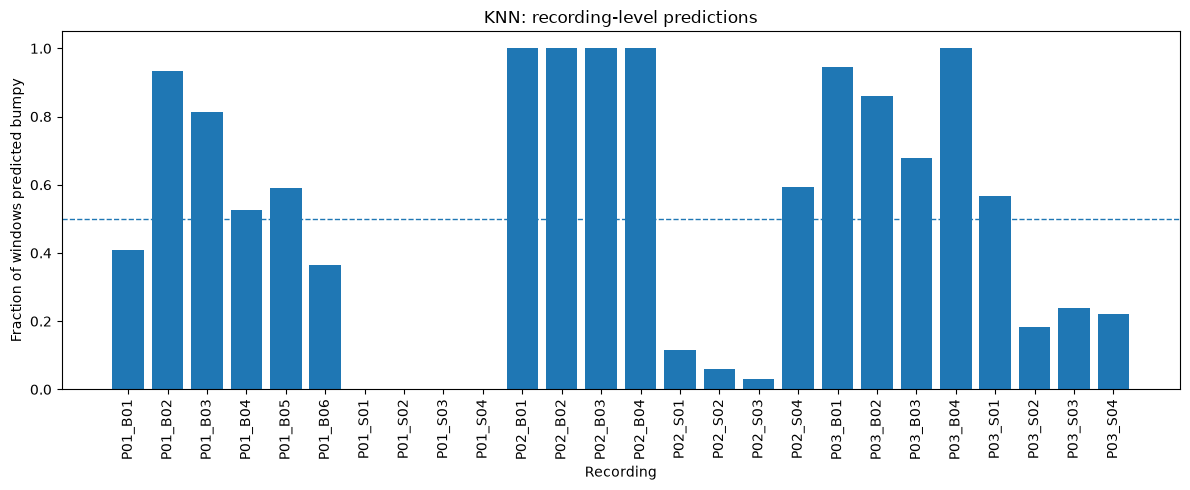

In [25]:
plt.figure(figsize=(12, 5))

x = np.arange(len(per_rec))

plt.bar(
    x,
    per_rec["frac_bumpy"],)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1)

plt.xticks(
    x,
    per_rec["recording_id"],
    rotation=90)

plt.ylabel("Fraction of windows predicted bumpy")
plt.xlabel("Recording")
plt.title("KNN: recording-level predictions")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "knn_per_recording.png",
    dpi=120,
    bbox_inches="tight")

plt.show()

## Save results

In [ ]:
per_fold.to_csv(
    RESULTS_DIR / "knn_metrics_per_fold.csv",
    index=False)

summary.to_csv(
    RESULTS_DIR / "knn_metrics_summary.csv")

predictions = df[
    ["recording_id", "participant", "label"]].copy()

predictions["pred"] = np.where(
    pred_lopo == 1,
    "bumpy",
    "smooth")

predictions.to_csv(
    RESULTS_DIR / "knn_predictions.csv",
    index=False)

per_rec.to_csv(
    RESULTS_DIR / "knn_predictions_per_recording.csv",
    index=False)

print("KNN results saved.")

KNN results saved.


In [27]:
print("Saved files:")

for path in sorted(RESULTS_DIR.glob("knn_*")):
    print(" -", path.name)

Saved files:
 - knn_metrics_per_fold.csv
 - knn_metrics_summary.csv
 - knn_predictions.csv
 - knn_predictions_per_recording.csv


In [ ]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 3.8),
    sharey=True)

for ax, (s, d) in zip(
    axes,
    k_curve.groupby("split", sort=False)):
    ax.plot(
        d["k"],
        d["train"],
        marker="o",
        markersize=4,
        label="train")

    ax.plot(
        d["k"],
        d["test"],
        marker="o",
        markersize=4,
        label="test (mean)")

    ax.plot(
        d["k"],
        d["worst test"],
        marker="o",
        markersize=4,
        linestyle="--",
        alpha=0.6,
        label="test (worst split)")

    ax.set(
        xlabel="number of neighbors (k)",
        title=s)

    ax.set_xticks(K_VALUES)

axes[0].set_ylabel("accuracy")
axes[0].legend(fontsize=8)

fig.tight_layout()
fig.savefig(
    FIG_DIR / "knn_k_curve.png",
    dpi=120,
    bbox_inches="tight")

plt.show()